In [16]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv(override=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Research Supervisor

*The supervisor has a simple job: delegate research tasks to an appropriate number of sub-agents.*

Here is our overall research flow:

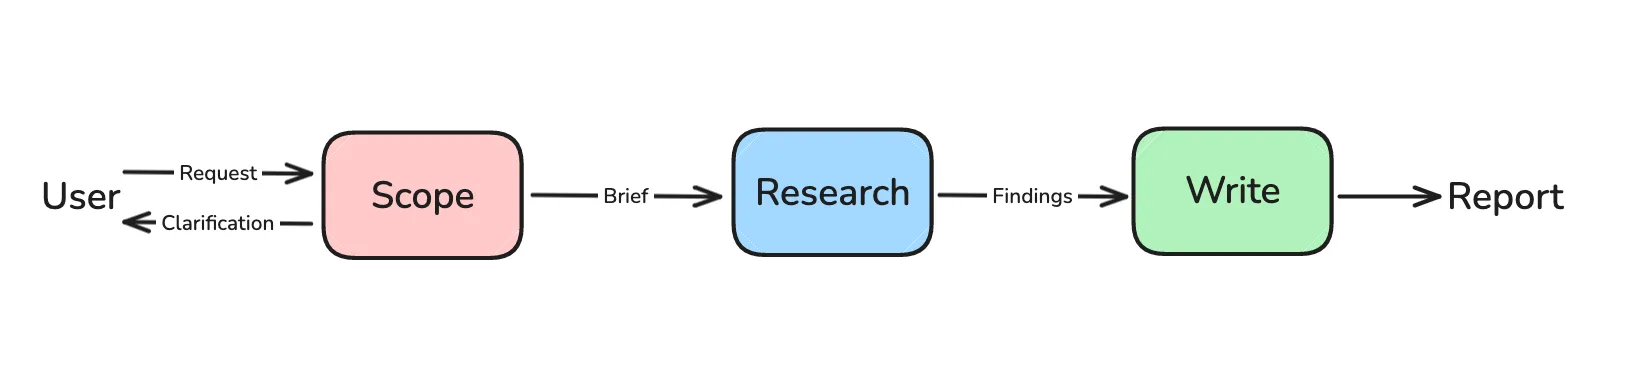

We previously built a research agent bound to either custom tools or MCP server. Now, what happens if the request is complex and has several sub-topics? Single agent response quality *can* suffer with multiple sub-topics (e.g., compare A to B to C) because a single context window needs to store and reason about tool feedback across all of the sub-topics. 

[Numerous failure modes](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), such as [context clash](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), become prevalent as the context window accumulates tool calls across many different sub-topics. As discussed in [Anthropic's blog post](https://www.anthropic.com/engineering/built-multi-agent-research-system), multi-agent systems can split sub-topic to sub-agents with isolated context windows. We'll build a system where a supervisor determines if the research brief can be broken-down into independent sub-topics and delegates to sub-agents with isolated context windows. 

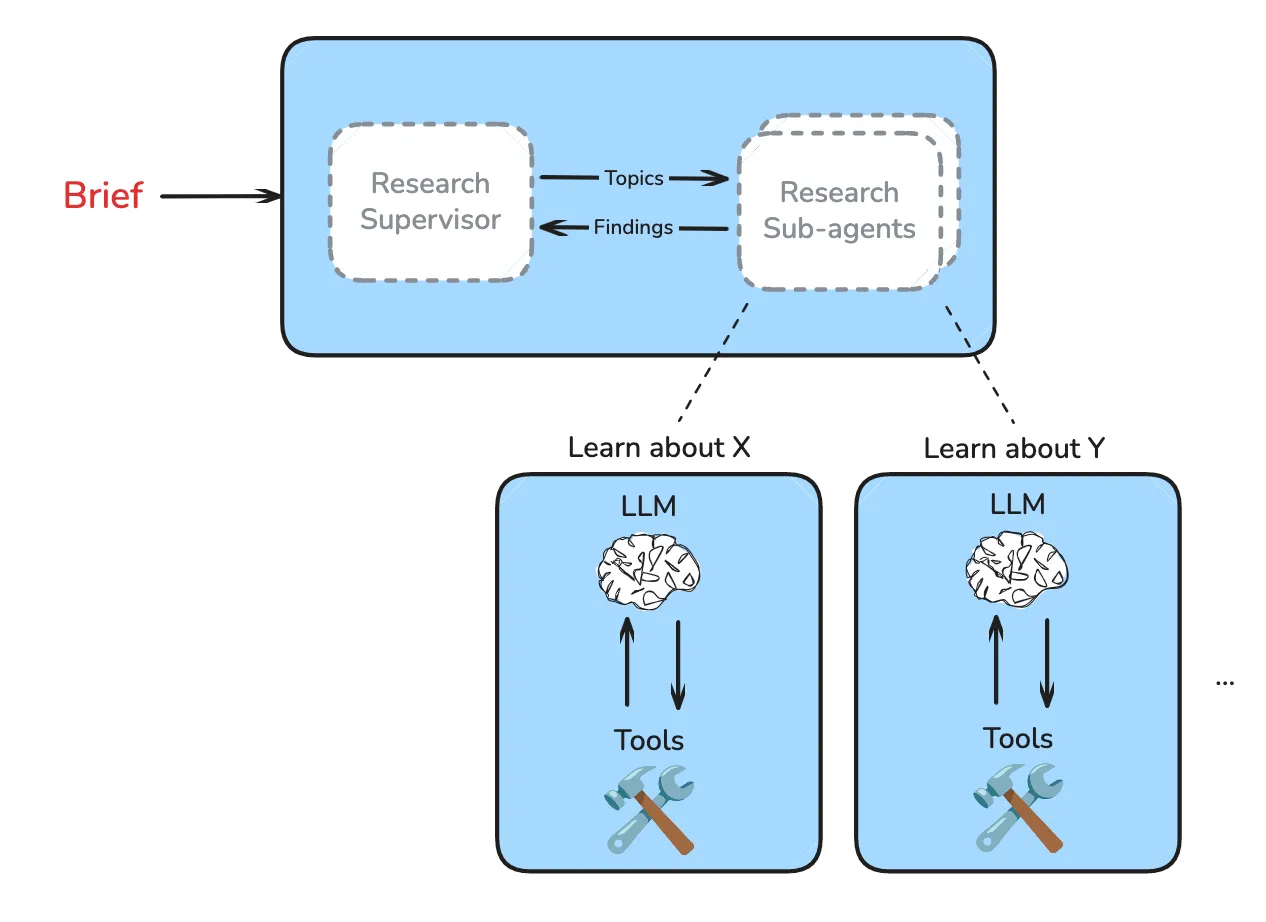

### Prompt

Now, let's design a prompt for the supervisor that follows the principles we've discussed, and include some insights from [the research literature](https://www.anthropic.com/engineering/built-multi-agent-research-system).

#### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the research. Are there multiple independent directions that can be explored simultaneously?
- **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still missing?

#### 2. Concrete Heuristics (For task delegation)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Bias towards single agent** - Use single agent for simplicity unless the user request has clear opportunity for parallelization. 
- **Stop when you can answer confidently** - Don't keep delegating research for perfection.
- **Limit tool calls** - Always stop after 3 tool calls to ConductResearch if you cannot find the right source(s).

#### 3. Show your thinking
Before you call ConductResearch tool call, use think_tool to plan your approach:
- Can the task be broken down into smaller sub-tasks?

After each ConductResearch tool call, use think_tool to analyze the results:
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

#### 4. Scaling rules
Simple fact-finding, lists, and rankings can use a single sub-agent.
- *Example*: List the top 10 coffee shops in San Francisco -> Use 1 sub-agent

Comparisons presented in the user request can use a sub-agent for each element of the comparison.
- *Example*: Compare OpenAI vs. Anthropic vs. DeepMind approaches to AI safety -> Use 3 sub-agents.
- Delegate clear, distinct, non-overlapping subtopics

In [17]:
from utils import show_prompt
from deep_research_from_scratch.prompts import lead_researcher_prompt
show_prompt(lead_researcher_prompt, "Lead Researcher Prompt")

╭──────────────────────────────────────────── Lead Researcher Prompt ─────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research supervisor. Your job is to conduct research by calling the "ConductResearch" tool. For      │
│  context, today's date is {date}.                                                                               │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your focus is to call the "ConductResearch" tool to conduct research against the overall research question     │
│  passed in by the user.                                                                                         │
│  When you are completely satisfied with the research findings returned from the tool calls, then you should     │
│  call the "ResearchComplete" tool to indicate that you are done with your research.                             │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to three main tools:                                                                           │
│  1. **ConductResearch**: Delegate research tasks to specialized sub-agents                                      │
│  2. **ResearchComplete**: Indicate that research is complete                                                    │
│  3. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool before calling ConductResearch to plan your approach, and after each                │
│  ConductResearch to assess progress**                                                                           │
│  **PARALLEL RESEARCH**: When you identify multiple independent sub-topics that can be explored simultaneously,  │
│  make multiple ConductResearch tool calls in a single response to enable parallel research execution. This is   │
│  more efficient than sequential research for comparative or multi-faceted questions. Use at most                │
│  {max_concurrent_research_units} parallel agents per iteration.                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a research manager with limited time and resources. Follow these steps:                             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the    │
│  research. Are there multiple independent directions that can be explored simultaneously?                       │
│  3. **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still         │
│  missing?                                                                                                       │
│  </Instructions>                                      

### State

The supervisor state manages the overall research coordination, while the researcher state handles individual research tasks.

In [18]:
%%writefile ../src/deep_research_from_scratch/state_multi_agent_supervisor.py

"""
State Definitions for Multi-Agent Research Supervisor

This module defines the state objects and tools used for the multi-agent
research supervisor workflow, including coordination state and research tools.
"""

import operator
from typing_extensions import Annotated, TypedDict, Sequence

from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

class SupervisorState(TypedDict):
    """
    State for the multi-agent research supervisor.
    
    Manages coordination between supervisor and research agents, tracking
    research progress and accumulating findings from multiple sub-agents.
    """
    
    # Messages exchanged with supervisor for coordination and decision-making
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]
    # Detailed research brief that guides the overall research direction
    research_brief: str
    # Processed and structured notes ready for final report generation
    notes: Annotated[list[str], operator.add] = []
    # Counter tracking the number of research iterations performed
    research_iterations: int = 0
    # Raw unprocessed research notes collected from sub-agent research
    raw_notes: Annotated[list[str], operator.add] = []

@tool
class ConductResearch(BaseModel):
    """Tool for delegating a research task to a specialized sub-agent."""
    research_topic: str = Field(
        description="The topic to research. Should be a single topic, and should be described in high detail (at least a paragraph).",
    )

@tool
class ResearchComplete(BaseModel):
    """Tool for indicating that the research process is complete."""
    pass

Overwriting ../src/deep_research_from_scratch/state_multi_agent_supervisor.py


### Multi-agent 

Now, we'll define our agent. A multi-agent system is a system that consists of multiple agents that work together to complete a task. The main benefit is context isolated, as discussed in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/). 

**Note:** The default settings here are for up to 3 research agents to run concurrently each with up to 6 calls to perform research.  This can take several minutes to run and depending on the users Tier, a 429 HTTP error (rate limit exceeded) *may* occur.  This may be avoided by raising the users's Tier to gain a better rate limit.  

Other less high thinking models may decide to run only a single research agent and perhaps avoid the rate limit error.  The point of this exercise, however, is to illustrate how concurrency of research agents may be achieved.


In [19]:
%%writefile ../src/deep_research_from_scratch/multi_agent_supervisor.py

"""Multi-agent supervisor for coordinating research across multiple specialized agents.

This module implements a supervisor pattern where:
1. A supervisor agent coordinates research activities and delegates tasks
2. Multiple researcher agents work on specific sub-topics independently
3. Results are aggregated and compressed for final reporting

The supervisor uses parallel research execution to improve efficiency while
maintaining isolated context windows for each research topic.
"""

import asyncio

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage, 
    BaseMessage, 
    SystemMessage, 
    ToolMessage,
    filter_messages
)
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

from deep_research_from_scratch.prompts import lead_researcher_prompt
from deep_research_from_scratch.research_agent import researcher_agent
from deep_research_from_scratch.state_multi_agent_supervisor import (
    SupervisorState, 
    ConductResearch, 
    ResearchComplete
)
from deep_research_from_scratch.utils import get_today_str, think_tool

def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """Extract research notes from ToolMessage objects in supervisor message history.
    
    This function retrieves the compressed research findings that sub-agents
    return as ToolMessage content. When the supervisor delegates research to
    sub-agents via ConductResearch tool calls, each sub-agent returns its
    compressed findings as the content of a ToolMessage. This function
    extracts all such ToolMessage content to compile the final research notes.
    
    Args:
        messages: List of messages from supervisor's conversation history
        
    Returns:
        List of research note strings extracted from ToolMessage objects
    """
    return [tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")]

# Ensure async compatibility for Jupyter environments
try:
    import nest_asyncio
    # Only apply if running in Jupyter/IPython environment
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass  # Not in Jupyter, no need for nest_asyncio
except ImportError:
    pass  # nest_asyncio not available, proceed without it


# ===== CONFIGURATION =====

supervisor_tools = [ConductResearch, ResearchComplete, think_tool]
supervisor_model = init_chat_model(model="openai:gpt-5.6-luna")
supervisor_model_with_tools = supervisor_model.bind_tools(supervisor_tools)

# System constants
# Maximum number of tool call iterations for individual researcher agents
# This prevents infinite loops and controls research depth per topic
max_researcher_iterations = 6 # Calls to think_tool + ConductResearch

# Maximum number of concurrent research agents the supervisor can launch
# This is passed to the lead_researcher_prompt to limit parallel research tasks
max_concurrent_researchers = 3

# ===== SUPERVISOR NODES =====

async def supervisor(state: SupervisorState) -> Command[Literal["supervisor_tools"]]:
    """Coordinate research activities.
    
    Analyzes the research brief and current progress to decide:
    - What research topics need investigation
    - Whether to conduct parallel research
    - When research is complete
    
    Args:
        state: Current supervisor state with messages and research progress
        
    Returns:
        Command to proceed to supervisor_tools node with updated state
    """
    supervisor_messages = state.get("supervisor_messages", [])
    
    # Prepare system message with current date and constraints
    system_message = lead_researcher_prompt.format(
        date=get_today_str(), 
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_researcher_iterations
    )
    messages = [SystemMessage(content=system_message)] + supervisor_messages
    
    # Make decision about next research steps
    response = await supervisor_model_with_tools.ainvoke(messages)
    
    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1
        }
    )

async def supervisor_tools(state: SupervisorState) -> Command[Literal["supervisor", "__end__"]]:
    """Execute supervisor decisions - either conduct research or end the process.
    
    Handles:
    - Executing think_tool calls for strategic reflection
    - Launching parallel research agents for different topics
    - Aggregating research results
    - Determining when research is complete
    
    Args:
        state: Current supervisor state with messages and iteration count
        
    Returns:
        Command to continue supervision, end process, or handle errors
    """
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]
    
    # Initialize variables for single return pattern
    tool_messages = []
    all_raw_notes = []
    next_step = "supervisor"  # Default next step
    should_end = False
    
    # Check exit criteria first
    exceeded_iterations = research_iterations >= max_researcher_iterations
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tool_call["name"] == "ResearchComplete" 
        for tool_call in most_recent_message.tool_calls
    )
    
    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END
    
    else:
        # Execute ALL tool calls before deciding next step
        try:
            # Separate think_tool calls from ConductResearch calls
            think_tool_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "think_tool"
            ]
            
            conduct_research_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "ConductResearch"
            ]

            # Handle think_tool calls (synchronous)
            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call["args"])
                tool_messages.append(
                    ToolMessage(
                        content=observation,
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    )
                )

            # Handle ConductResearch calls (asynchronous)
            if conduct_research_calls:
                # Launch parallel research agents
                coros = [
                    researcher_agent.ainvoke({
                        "researcher_messages": [
                            HumanMessage(content=tool_call["args"]["research_topic"])
                        ],
                        "research_topic": tool_call["args"]["research_topic"]
                    }) 
                    for tool_call in conduct_research_calls
                ]

                # Wait for all research to complete
                tool_results = await asyncio.gather(*coros)

                # Format research results as tool messages
                # Each sub-agent returns compressed research findings in result["compressed_research"]
                # We write this compressed research as the content of a ToolMessage, which allows
                # the supervisor to later retrieve these findings via get_notes_from_tool_calls()
                research_tool_messages = [
                    ToolMessage(
                        content=result.get("compressed_research", "Error synthesizing research report"),
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    ) for result, tool_call in zip(tool_results, conduct_research_calls)
                ]
                
                tool_messages.extend(research_tool_messages)

                # Aggregate raw notes from all research
                all_raw_notes = [
                    "\n".join(result.get("raw_notes", [])) 
                    for result in tool_results
                ]
                
        except Exception as e:
            print(f"Error in supervisor tools: {e}")
            should_end = True
            next_step = END
    
    # Single return point with appropriate state updates
    if should_end:
        return Command(
            goto=next_step,
            update={
                "notes": get_notes_from_tool_calls(supervisor_messages),
                "research_brief": state.get("research_brief", "")
            }
        )
    else:
        return Command(
            goto=next_step,
            update={
                "supervisor_messages": tool_messages,
                "raw_notes": all_raw_notes
            }
        )

# ===== GRAPH CONSTRUCTION =====

# Build supervisor graph
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)
supervisor_builder.add_edge(START, "supervisor")
supervisor_agent = supervisor_builder.compile()

Overwriting ../src/deep_research_from_scratch/multi_agent_supervisor.py


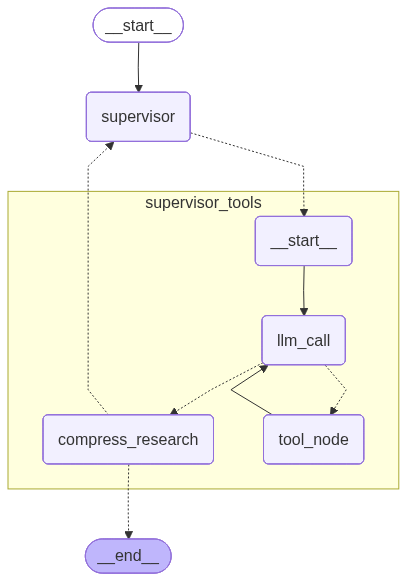

In [20]:
from IPython.display import Image, display
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# Show the agent
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

In [11]:
# Run the multi-agent supervisor agent
from utils import format_messages
from langchain_core.messages import HumanMessage

research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = await supervisor_agent.ainvoke({"supervisor_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['supervisor_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to identify and evaluate the coffee shops in San Francisco that are considered the best based            │
│ specifically                                                                                                    │
│ on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco    │
│ area,                                                                                                           │
│ using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,   │
│ expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,   │
│ location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary │
│ sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like  │
│ Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where      │
│ direct                                                                                                          │
│ customer feedback about coffee quality can be found. The study should result in a well-supported list or        │
│ ranking of                                                                                                      │
│ the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data  │
│ as                                                                                                              │
│ of July 2025..                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The user wants a well-supported ranking of the best coffee shops in San Francisco based        │
│ specifically on coffee quality. They want:\n1. Primary sources: official coffee shop websites, Coffee Review,   │
│ Specialty Coffee Association, Google/Yelp reviews\n2. Methods: expert reviews, customer ratings, specialty      │
│ coffee certifications\n3. Focus: coffee quality as primary criterion\n4. Latest data as of July 2025\n\nI       │
│ should break this into parallel research tasks:\n1. Expert reviews and specialty coffee certifications (Coffee  │
│ Review, SCA, James Beard, specialty coffee blogs/publications)\n2. Customer ratings and review aggregators      │
│ (Google, Yelp) focused on coffee quality in SF\n3. Top SF coffee shop roundups from reputable food/coffee       │
│ publications (Eater SF, SF Chronicle, Thrillist, Bon App\u00e9tit)\n\nThis is a good candidate for 3 parallel   │
│ agents covering different source types simultaneously."                                                         │
│ }                                                                                                               │
│    ID: toolu_01MNdEx2efjWnvctaExextZG                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The user wants a well-supported ranking of the best coffee shops in San Francisco based    │
│ specifically on coffee quality. They want:                                                                      │
│ 1. Primary sources: official coffee shop websites, Coffee Review, Specialty Coffee Association, Google/Yelp     │
│ reviews                                                                                                         │
│ 2. Methods: expert reviews, customer ratings, specialty coffee certifications                                   │
│ 3. Focus: coffee quality as primary criterion                                                                   │
│ 4. Latest data as of July 2025                                                                                  │
│                                                                                                                 │
│ I should break this into parallel research tasks:                                                               │
│ 1. Expert reviews and specialty coffee certifications (Coffee Review, SCA, James Beard, specialty coffee        │
│ blogs/publications)                                                                                             │
│ 2. Customer ratings and review aggregators (Google, Yelp) focused on coffee quality in SF                       │
│ 3. Top SF coffee shop roundups from reputable food/coffee publications (Eater SF, SF Chronicle, Thrillist, Bon  │
│ Appétit)                                                                                                        │
│                                                                                                                 │
│ This is a good candidate for 3 parallel agents covering different source types simultaneously.                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll now launch 3 parallel research agents to cover different source types simultaneously — expert/specialty    │
│ certifications, customer review platforms, and editorial roundups.                                              │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research the best coffee shops in San Francisco rated for coffee quality by expert sources │
│ and specialty coffee organizations. Focus on: (1) Coffee Review (coffeereview.com) ratings and reviews of San   │
│ Francisco roasters and cafes, (2) Specialty Coffee Association (SCA) certified or recognized coffee shops in    │
│ San Francisco, (3) Any barista competition winners or champion-affiliated cafes in San Francisco, (4) Sprudge   │
│ (sprudge.com) and other specialty coffee publications' rankings or features on San Francisco coffee shops as of │
│ 2024-2025. List the top-rated shops with specific scores, certifications, or expert commentary where            │
│ available."                                                                                                     │
│ }                                                                                                               │
│    ID: toolu_013PVDDy8LANJqVtUZvyJWKv                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research the best coffee shops in San Francisco with the highest customer ratings          │
│ specifically for coffee quality on Google Maps and Yelp as of 2024-2025. Search for San Francisco coffee shops  │
│ that are highly rated and where customer reviews specifically praise coffee quality, espresso quality,          │
│ single-origin offerings, pour-over quality, or overall coffee craftsmanship. List the top coffee shops with     │
│ their Google and/or Yelp ratings, number of reviews, and specific customer feedback about coffee quality.       │
│ Include shops like Sightglass Coffee, Ritual Coffee Roasters, Blue Bottle Coffee, Verve Coffee Roasters,        │
│ Equator Coffees, Sextant Coffee, and any others that rank highly."                                              │
│ }                                                                                                               │
│    ID: toolu_01Drec1GfJoJ4tdjC4yPC8qs                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research editorial and publication rankings of the best coffee shops in San Francisco      │
│ focused on coffee quality from 2024 to mid-2025. Look at sources including: (1) San Francisco Chronicle food    │
│ section, (2) Eater San Francisco (eater.com/san-francisco), (3) Thrillist San Francisco coffee guides, (4) Bon  │
│ App\u00e9tit or Food and Wine features on San Francisco coffee, (5) TimeOut San Francisco coffee rankings. For  │
│ each source, list which San Francisco coffee shops are ran

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **List of Queries and Tool Calls Made**                                                                         │
│                                                                                                                 │
│ 1. Coffee Review coffeereview.com highest rated San Francisco roasters cafes 2024                               │
│ 2. Sprudge best coffee shops San Francisco 2024 2025 specialty coffee                                           │
│ 3. Coffee Review 90+ scores San Francisco roasters Ritual Sightglass Linea Blue Bottle ratings                  │
│ 4. US Barista Championship winners San Francisco cafes 2023 2024 SCA competition                                │
│ 5. Frank La 2024 US Barista Champion coffee shop cafe affiliation roaster                                       │
│ 6. Sprudge San Francisco coffee shops best 2024 2025 Linea Saint Frank Andytown Wrecking Ball                   │
│ 7. coffeereview.com "San Francisco" OR "Ritual Coffee" OR "Sightglass" OR "Linea Caffe" OR "Wrecking Ball"      │
│ rated review score 95 96 97 98                                                                                  │
│ 8. Be Bright Coffee San Francisco Frank La cafe location specialty 2024 2025                                    │
│ 9. coffeereview.com top rated San Francisco Ritual Linea Sightglass Equator Wrecking Ball highest scores 2023   │
│ 2024                                                                                                            │
│ 10. Linea Caffe Andrew Barnett San Francisco expert reviews awards specialty coffee recognition 2024            │
│ 11. Equator Coffees Ritual Coffee Roasters Wrecking Ball "Coffee Review" score rating awards certifications     │
│ Good Food Award SCA                                                                                             │
│ 12. SPRO Coffee Lab San Francisco specialty coffee Sprudge best cafes SF 2024 Sightglass Saint Frank            │
│ recognition                                                                                                     │
│ 13. SF Chronicle best coffee San Francisco Bay Area 2024 list ranked cafes roasters Linea espresso              │
│ 14. Wrecking Ball Coffee Roasters Trish Rothgeb awards "Coffee Review" OR "Good Food Award" OR SCA 2024 San     │
│ Francisco recognition                                                                                           │
│ 15. SPRO Coffee Lab San Francisco owner barista judge credentials specialty coffee awards Ritual Coffee         │
│ Roasters Good Food Award Coffee Review 97 96 95                                                                 │
│ 16. Ritual Coffee Roasters "Coffee Review" OR "Good Food Award" OR "SCA" OR "Sprudge" awards recognition 2023   │
│ 2024 San Francisco                                                                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **Fully Comprehensive Findings**                                                                                │
│                                                                                                                 │
│ Coffee Review is a premier online platform offering expert evaluations of coffees and espressos, particularly   │
│ highlighting roasters and blends from the San Francisco area and beyond. Coffee Review has 265 reviews of       │
│ SF-area coffees documented. SF roasters reviewed include: Ritual Coffee Roasters, Equator Coffees, Highwire     │
│ Coffee Roasters, Thanksgiving Coffee Company, Sightglas

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **List of Queries and Tool Calls Made**                                                                         │
│                                                                                                                 │
│ 1. Search for "best coffee shops San Francisco 2024 2025 highest rated Google Maps Yelp coffee quality" [1].    │
│ 2. Search for "Sightglass Coffee Ritual Coffee Blue Bottle San Francisco ratings reviews 2024" [2].             │
│ 3. Search for "Ritual Coffee Roasters Verve Coffee Equator Coffees Sextant Coffee San Francisco Yelp Google     │
│ rating reviews 2024 2025" [3].                                                                                  │
│ 4. Search for "best specialty coffee San Francisco 2024 2025 espresso pour-over single origin reviews rankings" │
│ [4].                                                                                                            │
│ 5. Search for "Linea Caffe Saint Frank Coffee Sightglass Coffee San Francisco Yelp stars reviews google maps    │
│ rating 2024" [5].                                                                                               │
│ 6. Search for "top rated coffee shops San Francisco Yelp 4.5 stars espresso quality customer reviews 2024 2025  │
│ Sextant Equator Wrecking Ball" [6].                                                                             │
│ 7. Search for "Andytown Coffee Roasters Wrecking Ball Coffee Sextant Coffee Equator Coffees San Francisco       │
│ Google Maps Yelp rating stars reviews coffee quality" [7].                                                      │
│ 8. Search for '"Ritual Coffee" "Blue Bottle Coffee" "Sightglass Coffee" "Verve Coffee" San Francisco customer   │
│ reviews espresso pour over single origin 2024 2025' [8].                                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **Fully Comprehensive Findings**                                                                                │
│                                                                                                                 │
│ - The Ironclad List—top SF coffee shops, detailing ratings, reviews, and customer praise for                    │
│ coffee/espresso/single-origin/craftsmanship:                                                                    │
│                                                                                                                 │
│ **Sightglass Coffee**                                                                                           │
│ - "Sightglass Coffee is an independent, sibling-owned organic coffee company founded in 2009 in San Francisco,  │
│ CA. Starting with a single espresso machine behind a roll-up door in an old warehouse, it has grown to operate  │
│ two roasteries, four flagship cafés, and over 500 wholesale accounts nationwide, establishing itself as one of  │
│ the top coffee producers globally. Their coffee is USDA Certified Organic and sourced directly from smallholder │
│ farms dedicated to sustainable and freshly harvested coffee. Sightglass emphasizes small-batch roasting and     │
│ meticulous attention to detail, reflecting a distinctly Californian spirit. Key offerings include the Spring    │
│ Equinox Blend, a balanced 50/50 Guatemala and Honduras blend noted for its apricot sweetness, orange blossom    │
│ florals, and chocolate ganache finish. Beginning in 2024, all grocery offerings will be USDA Certified Organic  │
│ by CCOF. Sightglass partners with producers worldwide, 

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **List of Queries and Tool Calls Made**                                                                         │
│                                                                                                                 │
│ 1. Searched for “San Francisco Chronicle best coffee shops 2024 2025 coffee quality rankings”                   │
│ 2. Searched for “Eater San Francisco best coffee shops 2024 2025 rankings coffee quality”                       │
│ 3. Searched for “Thrillist San Francisco best coffee shops 2024 2025 guide”                                     │
│ 4. Searched for “Thrillist ‘San Francisco’ best coffee 2024 2025 site:thrillist.com”                            │
│ 5. Searched for “TimeOut San Francisco best coffee shops 2024 2025 rankings”                                    │
│ 6. Searched for “Bon Appetit Food Wine San Francisco best coffee shops 2024 2025”                               │
│ 7. Searched for “thrillist.com San Francisco best coffee shops guide 2024 2025 espresso roasters”               │
│ 8. Searched for “site:sfchronicle.com best coffee San Francisco 2024 2025 Linea Saint Frank Sightglass Ritual”  │
│ 9. Searched for “Bon Appetit best coffee San Francisco 2024 OR ‘Food and Wine’ best coffee San Francisco 2024   │
│ 2025 roasters espresso”                                                                                         │
│ 10. Searched for “sfchronicle.com 2025 best coffee Bay Area Komakase Saint Frank Linea Hedge Sightglass Ritual  │
│ coffee quality”                                                                                                 │
│ 11. Searched for “'Food & Wine' OR 'foodandwine.com' San Francisco best coffee cities 2025 Abanico Ritual       │
│ Sightglass”                                                                                                     │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **Fully Comprehensive Findings**                                                                                │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ **San Francisco Chronicle — “Best Coffee in the San Francisco Bay Area” (2026 edition)**                        │
│ - This comprehensive guide by Cesar Hernandez highlights the best coffee shops in the San Francisco Bay Area as │
│ of 2026, showcasing a dynamic and evolving coffee scene with influences from Japanese, Korean, and Chinese      │
│ cultures. The article covers a wide range of cafes, each offering unique coffee experiences, from traditional   │
│ espresso drinks to experimental brews involving fruit fermentation and specialty syrups. Notable cafes include  │
│ Ain’t Normal Cafe offering diverse roaster selections in Oakland; Backhaus, a German-style bakery in San Mateo  │
│ with Ritual Coffee beans; The Caffè in Oakland, featuring Italian-style roasts; The Coffee Movement in San      │
│ Francisco with unique drinks and roasting; and Olivia Coffee and Flower in Oakland, specializing in Korean      │
│ roasted beans. It also profiles Vietnamese specialty coffee at Lacàphê in San Jose and Chinese coffee culture   │
│ at Berkeley’s Masterpiece Coffee. Many shops emphasize innovative drinks such as espresso tonics, coffee cream  │
│ sodas, and seasonal lattes. The guide also points out t

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I now have a very comprehensive set of findings from three parallel research agents. Let me    │
│ assess what I have:\n\n**Expert/Specialty Sources:**\n- Coffee Review: Has 265+ SF reviews. Named SF roasters   │
│ include Ritual, Equator, Linea, Sightglass, Wrecking Ball. Specific scores not surfaced but their SF city page  │
│ is confirmed.\n- Good Food Awards 2026 winners from SF/Bay Area: Equator Coffees (Colombia Las Flores Thermal   │
│ Shock Pink Bourbon) and Linea Caffe (Organic Ethiopia Gotiti Yirgacheffe Reserve)\n- Linea Caffe: B Corp        │
│ certified, CCOF organic certification (first fully certified organic roaster in SF), Good Food Award 2024 and   │
│ 2026, Food & Wine \"America's Best Independent Coffee Shops,\" Andrew Barnett is a World Barista Championship   │
│ judge\n- Equator Coffees: B Corp certified, Good Food Award 2026\n- Wrecking Ball Coffee: Founded by Trish      │
│ Rothgeb (coined \"third wave coffee\")\n- Ritual Coffee: Woman-owned, direct trade, specialty grade\n-          │
│ Sightglass: USDA Certified Organic, CCOF certified beginning 2024\n\n**Customer Ratings (Yelp/Google):**\n-     │
│ Andytown Coffee Roasters: Yelp 4.5, 1,200+ reviews (Lawton flagship)\n- Sightglass Coffee: TripAdvisor 4.5/5,   │
│ Yelp 4.0\u20134.5, 1,000+ reviews\n- Blue Bottle Coffee: TripAdvisor 4.5 (614 reviews), Yelp 4.0\u20134.5\n-    │
│ Saint Frank Coffee: Yelp 4.3 (1,000+ reviews)\n- Capital One Caf\u00e9 (Verve): Yelp 4.3 (502 reviews)\n- Paper │
│ Son Coffee: Yelp 4.5 (71 reviews)\n- Ritual Coffee: Yelp 4.0\u20134.5\n\n**Editorial Rankings:**\n\nEater SF    │
│ 2026 Top 17 (focused on coffee quality):\n1. Caffe Trieste\n2. Capital One Cafe (Verve Coffee)\n3. Cafe         │
│ Shoji\n4. Scullery (Mother Tongue Coffee)\n5. Paper Son - \"crowning achievement... top-tier espresso and       │
│ pour-over skills\"\n6. Hi NRG\n7. Delah Coffee House (Yemeni coffee)\n8. Golden Goat Coffee (stocks world's     │
│ most sought-after roasters)\n9. Saint Frank Coffee - \"mythical\" espresso, first Kaffe Tonic in CA\n10. Linea  │
│ Coffee Roasting - \"Andrew Barnett is a mythical San Francisco espresso savant\"\n11. Hedge Coffee Roasters     │
│ (on-site roasting)\n12. The Coffee Movement at Side A\n13. Grand Coffee\n14. Pinhole Coffee\n15. Hey Neighbor   │
│ Cafe (Captain + Stoker beans)\n16. Excelsior Coffee\n17. Better Half Coffee\n\nThrillist SF Top 13:\n1. Abanico │
│ Coffee Roasters (house-roasted beans)\n2. Grand Coffee (excellent espresso, single-origin)\n3. Wrecking Ball    │
│ Coffee Roasters (sustainably sourced pour-over)\n4. Sextant Coffee Roasters (direct trade,                      │
│ Ethiopia/Kenya/Colombia)\n5. Verve Coffee Roasters\n6. Andytown Coffee Roasters\n7. Pinhole Coffee\n8. Equator  │
│ Coffees (sustainability, transparency)\n9. Caffe Trieste\n10. Ritual Coffee Roasters (specialty grade, direct   │
│ from farmers)\n11. Saint Frank Coffee (named one of 21 best in country, small-scale specialty beans)\n12. Linea │
│ Caffe (former World Barista Championship judge, organic producers)\n13. Flywheel Coffee Roasters\n\nTimeOut SF  │
│ Top 13:\nAndytown, Equator, Farley's, Rise & Grind, Flywheel, Sightglass, Ritual, Sextant, Saint Frank, Linea,  │
│ Four Barrel, Philz, Blue Bottle\n\nSF Chronicle 2026: Komakase (Bay Area's first coffee omakase), Olivia        │
│ Coffee, Saint Frank, The Crown (Oakland), The Coffee Movement, Masterpiece Coffee, Lac\u00e0ph\u00ea, Backhaus, │
│ Ain't Normal Cafe, Kaizen & Coffee\n\n**Cross-Source Ran

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I now have a very comprehensive set of findings from three parallel research agents. Let   │
│ me assess what I have:                                                                                          │
│                                                                                                                 │
│ **Expert/Specialty Sources:**                                                                                   │
│ - Coffee Review: Has 265+ SF reviews. Named SF roasters include Ritual, Equator, Linea, Sightglass, Wrecking    │
│ Ball. Specific scores not surfaced but their SF city page is confirmed.                                         │
│ - Good Food Awards 2026 winners from SF/Bay Area: Equator Coffees (Colombia Las Flores Thermal Shock Pink       │
│ Bourbon) and Linea Caffe (Organic Ethiopia Gotiti Yirgacheffe Reserve)                                          │
│ - Linea Caffe: B Corp certified, CCOF organic certification (first fully certified organic roaster in SF), Good │
│ Food Award 2024 and 2026, Food & Wine "America's Best Independent Coffee Shops," Andrew Barnett is a World      │
│ Barista Championship judge                                                                                      │
│ - Equator Coffees: B Corp certified, Good Food Award 2026                                                       │
│ - Wrecking Ball Coffee: Founded by Trish Rothgeb (coined "third wave coffee")                                   │
│ - Ritual Coffee: Woman-owned, direct trade, specialty grade                                                     │
│ - Sightglass: USDA Certified Organic, CCOF certified beginning 2024                                             │
│                                                                                                                 │
│ **Customer Ratings (Yelp/Google):**                                                                             │
│ - Andytown Coffee Roasters: Yelp 4.5, 1,200+ reviews (Lawton flagship)                                          │
│ - Sightglass Coffee: TripAdvisor 4.5/5, Yelp 4.0–4.5, 1,000+ reviews                                            │
│ - Blue Bottle Coffee: TripAdvisor 4.5 (614 reviews), Yelp 4.0–4.5                                               │
│ - Saint Frank Coffee: Yelp 4.3 (1,000+ reviews)                                                                 │
│ - Capital One Café (Verve): Yelp 4.3 (502 reviews)                                                              │
│ - Paper Son Coffee: Yelp 4.5 (71 reviews)                                                                       │
│ - Ritual Coffee: Yelp 4.0–4.5                                                                                   │
│                                                                                                                 │
│ **Editorial Rankings:**                                                                                         │
│                                                                                                                 │
│ Eater SF 2026 Top 17 (focused on coffee quality):                                                               │
│ 1. Caffe Trieste                                                                                                │
│ 2. Capital One Cafe (Verve Coffee)                                                                              │
│ 3. Cafe Shoji                                                                                                   │
│ 4. Scullery (Mother Tongue Coffee)                                                                              │
│ 5. Paper Son - "crowning achievement... top-tier espresso and pour-over skills"                                 │
│ 6. Hi NRG                                              

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: ResearchComplete                                                                                  │
│    Args: {}                                                                                                     │
│    ID: toolu_01CqSJbeFX36Tt32S2aFk4Gq                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

We can look at the trace [here](https://smith.langchain.com/public/99eaaecd-fd9a-4ead-8eed-abdfe4ab9288/r).

### LangGraph Studio

Just as we did before, we can also use LangGraph Studio to visualize the agent. 

This agent has been added to the `langgraph.json` file, so you can select `research_agent_supervisor` in the dropdown menu:

```
"research_agent_supervisor": "./src/deep_research_from_scratch/multi_agent_supervisor.py:supervisor_agent",
```

Run the following command to start the studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## Eval

The clear benefit of multi-agent is context isolation when there are clearly separable sub-topics. As we discuss [in our blog](https://blog.langchain.com/open-deep-research/): 

> Our experiments showed that single agent response quality suffers if the request has multiple sub-topics (e.g., compare A to B to C). The intuition here is straightforward: a single context window needs to store and reason about tool feedback across all of the sub-topics. This tool feedback is often token heavy. Numerous failure modes, such as context clash, become prevalent as the context window accumulates tool calls across many different sub-topics.

But, we want to be careful not to spawn sub-agents in cases where it is not required:

> The supervisor can handle both cases by selectively spawning sub-agents to tune the level of research depth needed for a request. The supervisor is prompted with heuristics to reason about when research should be parallelized, and when a single thread of research is sufficient. Our deep research agent has the flexibility to choose whether to parallelize research or not.

Let's set up a few tests to make sure that we are parallelizing when it makes sense.

In [21]:
# Example messages with think_tool calls and tool messages for evaluation
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

should_parallelize = [
    HumanMessage(content="Compare OpenAI vs Gemini deep research."),
    AIMessage(content="I need to analyze this request to determine if can should be parallelized.", tool_calls=[
        {
            "name": "think_tool",
            "args": {"reflection": "This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research."},
            "id": "call_think_1"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research.", tool_call_id="call_think_1", name="think_tool")
]

should_not_parallelize = [
    HumanMessage(content="What are the top three Chinese restaurants in Chelsea, Manhattan"),
    AIMessage(content="Let me think about whether this task requires parallelization.", tool_calls=[
        {
            "name": "think_tool", 
            "args": {"reflection": "This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan)."},
            "id": "call_think_2"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan).", tool_call_id="call_think_2", name="think_tool")
]

In [22]:
import os
from langsmith import Client

# Initialize client 
langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# Create the dataset
dataset_name = "deep_research_supervisor_parallelism"
if not langsmith_client.has_dataset(dataset_name=dataset_name):

    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="A dataset that evaluates whether a supervisor can accurately decide when to parallelize research.",
    )

    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"supervisor_messages": should_parallelize},
                "outputs": {"num_expected_threads": 2},
            },
            {
                "inputs": {"supervisor_messages": should_not_parallelize},
                "outputs": {"num_expected_threads": 1},
            },
        ],
    )

Now we can run evals.

In [23]:
import uuid

def evaluate_parallelism(outputs: dict, reference_outputs:dict):
    tool_calls = outputs["output"].update["supervisor_messages"][-1].tool_calls
    return {
        "key": "correct_next_step",
        "score": len(tool_calls) == reference_outputs["num_expected_threads"]
    }

async def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    return await supervisor_agent.nodes["supervisor"].ainvoke(inputs, config=config)

await langsmith_client.aevaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_parallelism],
    experiment_prefix="Supervisor Parallelism",
)

View the evaluation results for experiment: 'Supervisor Parallelism-9c419d6d' at:
https://smith.langchain.com/o/0b77add7-b8e6-47f1-ac77-41b7c9f1a0ec/datasets/76fae494-54b4-402a-adab-cb3526edd2c3/compare?selectedSessions=2263e27e-7c64-42a1-ba6b-2d461c0eb8fe




0it [00:00, ?it/s]

<AsyncExperimentResults Supervisor Parallelism-9c419d6d>

In the first example, we asked the agent to compare and contrast products.

This sort of problem is great for parallel research, and we expect the agent to deep dive into each lab in parallel before synthesizing findings when writing the report.

The second example asks the agent for the top restaurants in Chelsea, Manhattan. 

The agent needs to conduct a single thread of research here and reflect on websites that presumably list out highly rated restaurants. 

There's not an obvious opportunity for parallelism for this ranking task.